# 🚀 M1MLOP — Jour 1 : Fondements MLOps
**École IT — Master 1 — Unité 3 BigData — Semaine 11**

---

## 🗂️ Table des matières
1. [Contexte et objectifs](#1)
2. [Les défis de la production ML](#2)
3. [Qu'est-ce que le MLOps ?](#3)
4. [Cycle de vie MLOps](#4)
5. [MLflow — Introduction et installation](#5)
6. [TP 1.1 — MLflow Tracking](#6)
7. [TP 1.2 — MLflow Registry](#7)
8. [Reproductibilité et seeds](#8)
9. [Résumé et bilan du Jour 1](#9)

---

> 📌 **Prérequis** : Python, scikit-learn, Pandas/NumPy (M1U2), bases Docker/DevOps  
> ⏱️ **Durée estimée** : 7h (matinée + après-midi)

<a id='1'></a>
## 1. 🎯 Contexte et Objectifs du Jour 1

### Pourquoi ce module ?

> **Statistique clé** : 87% des projets ML n'atteignent jamais la production *(Gartner)*.

En formation ML, on apprend à construire des modèles avec de bonnes performances. Mais en entreprise, **un modèle n'a de valeur que s'il tourne en production**, de façon fiable, reproductible et maintenable dans le temps.

C'est exactement le problème que résout **MLOps**.

### Objectifs du Jour 1

À la fin de cette journée, tu seras capable de :
- ✅ Comprendre les défis fondamentaux de la production ML en entreprise
- ✅ Maîtriser le cycle de vie complet d'un modèle ML (dev → prod → monitoring)
- ✅ Utiliser **MLflow** pour versionner, tracker et déployer des modèles
- ✅ Mettre en place un **registre de modèles** professionnel
- ✅ Implémenter la **reproductibilité** et la gouvernance des modèles

### 💼 Métiers concernés

| Métier | Salaire moyen |
|---|---|
| MLOps Engineer | 60–100K€ |
| ML Engineer | 55–95K€ |
| Data Scientist Senior (end-to-end) | 55–90K€ |
| Platform Engineer ML | 65–105K€ |
| AI Infrastructure Engineer | 70–120K€ |

<a id='2'></a>
## 2. ⚠️ Les Défis de la Mise en Production ML

### 2.1 Le fossé Développement ↔ Production

En développement, tu travailles avec un **dataset statique**. En production, les données changent en permanence :

| Problème | Description | Exemple concret |
|---|---|---|
| **Data Drift** | Les données d'entrée changent | Nouvelles catégories de clients |
| **Concept Drift** | La relation données→cible change | Comportement client post-COVID |
| **Latence** | Répondre en ms, pas en minutes | Fraude détectée en < 200ms |
| **Scalabilité** | Passer de 1K à 100K requêtes/jour | Black Friday |

> 💼 **Cas réel — Netflix** : Sans monitoring automatisé, une dégradation de 1% de précision = 1 million d'utilisateurs avec de mauvaises recommandations. MLOps détecte cela en **heures**, pas en semaines.

### 2.2 La Reproductibilité

Problème critique en entreprise : *"Mon modèle marchait hier, pourquoi plus aujourd'hui ?"*

MLOps fournit :
- **Versioning du code ET des données** (pas seulement Git)
- **Tracking des hyperparamètres** et des expériences
- **Audit trail** complet (qui a déployé quoi, quand, pourquoi)
- **Rollback automatique** en cas de problème

> 🏦 **Secteur financier** : Les régulateurs bancaires exigent une traçabilité complète des décisions ML (crédit, fraude). MLOps crée cet *audit trail* automatiquement, répondant aux normes **RGPD** et de conformité.

### 2.3 Les acteurs impliqués

MLOps relie plusieurs équipes souvent **silotées** :

| Acteur | Responsabilités | Outils MLOps |
|---|---|---|
| **Data Scientist** | Expérimentation, modélisation | MLflow, Jupyter, tracking |
| **ML Engineer** | Pipeline, productionisation | Airflow, CI/CD, Docker |
| **DevOps/SRE** | Déploiement, infrastructure | K8s, Prometheus, API |

<a id='3'></a>
## 3. 🔧 Qu'est-ce que le MLOps ?

**MLOps = Machine Learning Operations**

C'est l'application des principes **DevOps** au Machine Learning.

### Les 5 Piliers du MLOps

```
┌─────────────────────────────────────────────────────────────┐
│                    LES 5 PILIERS MLOPS                      │
├──────────────────┬──────────────────────────────────────────┤
│ 🔁 Reproductibilité │ Rejouer exactement un modèle d'il y a 6 mois │
│ 🤖 Automation       │ Entraînement, tests, déploiement sans humain  │
│ 📊 Monitoring        │ Détecter les dégradations avant les users     │
│ 📦 Versioning        │ Modèles, données, code — tout versionné       │
│ 🤝 Collaboration     │ Data Scientists + ML Eng + Ops ensemble       │
└──────────────────┴──────────────────────────────────────────┘
```

> 🏭 **Industrie 4.0** : Une usine avec 1000 capteurs ML. Sans MLOps, quand un modèle échoue, l'usine s'arrête. Avec MLOps, on a du monitoring et du retraining automatique — l'usine tourne **24/7**.

<a id='4'></a>
## 4. 🔄 Cycle de Vie MLOps

### Software classique vs ML

**Software classique :**
```
Write Code → Test → Deploy → Monitor → Fix → Repeat
```

**Machine Learning (3 boucles) :**

```
┌── BOUCLE 1 : Expérimentation (Data Scientist) ──────────────┐
│  Data Collection → Preprocessing → Feature Eng → Training → Eval │
└──────────────────────────────────────────────────────────────┘
         ↓ si bon modèle
┌── BOUCLE 2 : Production (ML Engineer) ──────────────────────┐
│  Code Review → Testing → CI/CD → Deployment → Monitoring        │
└──────────────────────────────────────────────────────────────┘
         ↓ si drift détecté
┌── BOUCLE 3 : Retraining (Automatisé via MLOps) ─────────────┐
│  Drift Detection → Data Collection → Retraining → Validation │
│  → Auto-Deploy                                                │
└──────────────────────────────────────────────────────────────┘
```

Ce qui rend MLOps unique : la **boucle 3**. Un modèle n'est jamais "fini".

> 💬 **Modération de contenu (Meta/Facebook)** : Les modèles de détection de haine/spam sont réentraînés **toutes les semaines** car les contenus malveillants évoluent. MLOps automatise ce retraining.

<a id='5'></a>
## 5. 📦 MLflow — Installation et Configuration

**MLflow** est un framework open-source créé par Databricks. C'est le **standard de l'industrie** pour le tracking et le versioning de modèles ML.

### Les 4 composants de MLflow

| Composant | Rôle |
|---|---|
| **Tracking** | Logger les expériences (hyperparamètres, métriques, artefacts) |
| **Projects** | Empaqueter le code de façon reproductible |
| **Models** | Standardiser le format et le déploiement |
| **Registry** | Gérer les versions en production |

> 🔧 **AWS SageMaker Experiments** propose une alternative propriétaire, mais MLflow est plus portable et open-source. Utilisé chez Airbnb, Hugging Face et OpenAI.

In [1]:
# ============================================================
# 📦 INSTALLATION DES DÉPENDANCES
# Exécuter cette cellule en premier !
# ============================================================
import sys

!{sys.executable} -m pip install mlflow scikit-learn pandas numpy matplotlib seaborn --quiet

print("✅ Installation terminée !")

✅ Installation terminée !


In [2]:
# ============================================================
# 📚 IMPORTS GLOBAUX
# ============================================================
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

import numpy as np
import pandas as pd
import random
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

print(f"✅ MLflow version : {mlflow.__version__}")
print(f"✅ Tous les imports OK")

✅ MLflow version : 3.10.1
✅ Tous les imports OK


<a id='8'></a>
## 6. 🎲 Reproductibilité et Seeds

### Pourquoi fixer les seeds ?

Problème critique en ML : *"Mon résultat diffère chaque fois que j'exécute le code"*.

En fixant les seeds, on garantit que :
- Les splits train/test sont **identiques** à chaque run
- Les modèles avec randomness (Random Forest) sont **reproductibles**
- Les résultats peuvent être **vérifiés** et **audités**

> 🔬 **Crise de reproductibilité en ML** : Beaucoup d'articles ML ne peuvent pas être reproduits car les seeds n'étaient pas fixés. `MLflow + seeds` résout ce problème.

In [4]:
# ============================================================
# 🎲 FIXER LES SEEDS POUR LA REPRODUCTIBILITÉ
# ============================================================

SEED = 42  # Convention : 42 est le seed le plus utilisé en ML

np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Vérification : deux appels identiques doivent donner le même résultat
np.random.seed(SEED)
arr1 = np.random.randint(0, 100, 5)

np.random.seed(SEED)
arr2 = np.random.randint(0, 100, 5)

print(f"Array 1 : {arr1}")
print(f"Array 2 : {arr2}")
print(f"Identiques : {np.array_equal(arr1, arr2)} ✅" if np.array_equal(arr1, arr2) else "⚠️ Problème de seed !")

Array 1 : [51 92 14 71 60]
Array 2 : [51 92 14 71 60]
Identiques : True ✅


<a id='6'></a>
## 7. 🧪 TP 1.1 — MLflow Tracking

### Objectif
Créer une expérience MLflow qui teste **3 configurations de modèles différentes** et visualiser les résultats dans l'UI.

### Les 3 concepts clés de MLflow Tracking

| Méthode | Type de données | Exemple |
|---|---|---|
| `mlflow.log_param()` | Hyperparamètres (immutables) | `n_estimators=100` |
| `mlflow.log_metric()` | Performances (évoluent) | `accuracy=0.95` |
| `mlflow.log_model()` | Le modèle lui-même | `model.pkl` |

### Dataset utilisé : Iris
Le dataset **Iris** contient 150 fleurs avec 4 mesures chacune (longueur/largeur de sépale et pétale), à classifier en 3 espèces.

### Étapes du TP
1. Charger et explorer le dataset Iris
2. Créer une expérience MLflow
3. Tester 3 modèles différents (Random Forest, Gradient Boosting, SVM)
4. Logger params + métriques + modèle pour chaque run
5. Identifier le meilleur modèle

In [5]:
# ============================================================
# ÉTAPE 1 : Charger et explorer le dataset Iris
# ============================================================

iris = load_iris()
X, y = iris.data, iris.target

# Créer un DataFrame pour la visualisation
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

print("📊 Aperçu du dataset :")
print(df.head())
print(f"\n📐 Dimensions : {df.shape}")
print(f"🌸 Classes : {iris.target_names.tolist()}")
print(f"📋 Features : {iris.feature_names}")
print(f"\n🔢 Distribution des classes :")
print(df['species'].value_counts())

📊 Aperçu du dataset :
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

📐 Dimensions : (150, 5)
🌸 Classes : ['setosa', 'versicolor', 'virginica']
📋 Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

🔢 Distribution des classes :
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


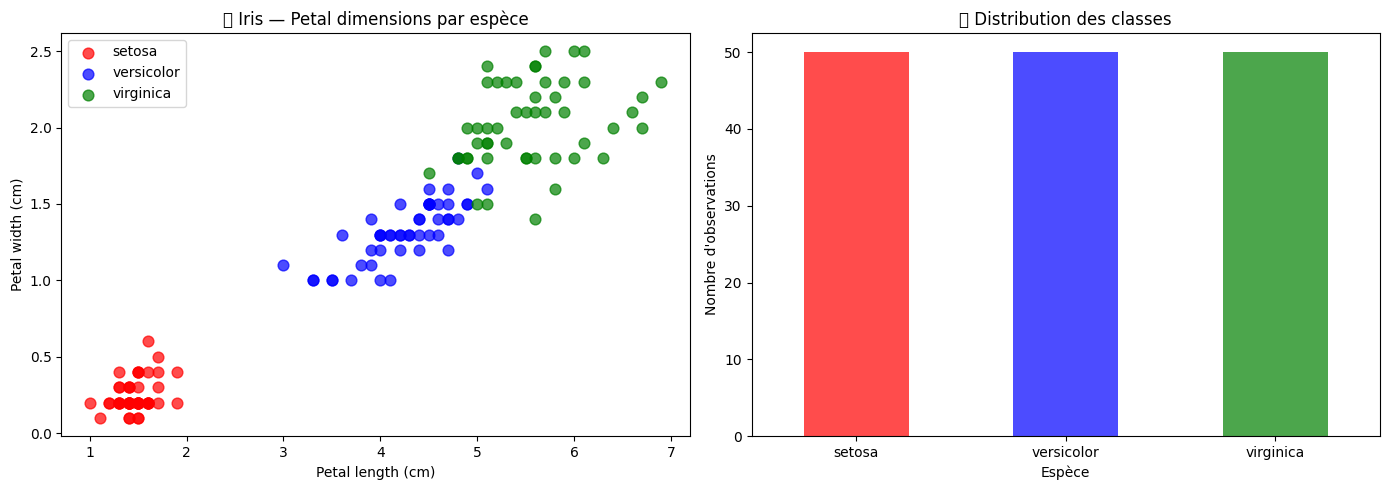

📸 Graphique sauvegardé : iris_exploration.png


In [6]:
# ============================================================
# VISUALISATION DU DATASET
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot : 2 features
colors = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}
for species, color in colors.items():
    mask = df['species'] == species
    axes[0].scatter(
        df[mask]['petal length (cm)'],
        df[mask]['petal width (cm)'],
        c=color, label=species, alpha=0.7, s=60
    )
axes[0].set_xlabel('Petal length (cm)')
axes[0].set_ylabel('Petal width (cm)')
axes[0].set_title('🌸 Iris — Petal dimensions par espèce')
axes[0].legend()

# Distribution des classes
df['species'].value_counts().plot(kind='bar', ax=axes[1], color=['red','blue','green'], alpha=0.7)
axes[1].set_title('📊 Distribution des classes')
axes[1].set_xlabel('Espèce')
axes[1].set_ylabel('Nombre d\'observations')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('iris_exploration.png', dpi=100, bbox_inches='tight')
plt.show()
print("📸 Graphique sauvegardé : iris_exploration.png")

In [7]:
# ============================================================
# ÉTAPE 2 : Préparer le split train/test
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y  # Garder la même distribution dans train et test
)

print(f"✅ Split effectué :")
print(f"   Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n📋 Distribution dans le train :")
for i, name in enumerate(iris.target_names):
    count = np.sum(y_train == i)
    print(f"   {name}: {count} samples")

✅ Split effectué :
   Train : 120 samples (80%)
   Test  : 30 samples (20%)

📋 Distribution dans le train :
   setosa: 40 samples
   versicolor: 40 samples
   virginica: 40 samples


In [8]:
# ============================================================
# ÉTAPE 3 : MLflow Tracking — 3 modèles différents
# ============================================================

# Configurer l'URI MLflow (stockage local par défaut)
mlflow.set_tracking_uri("mlruns")  # Dossier local 'mlruns'

# Créer / sélectionner l'expérience
EXPERIMENT_NAME = "iris_classification_tp1"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Expérience MLflow configurée : '{EXPERIMENT_NAME}'")
print(f"📁 Les runs seront stockés dans : ./mlruns/")

# Définir les 3 configurations à tester
configs = [
    {
        "run_name": "RandomForest_v1",
        "model_type": "RandomForest",
        "model": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED),
        "params": {"n_estimators": 100, "max_depth": 5}
    },
    {
        "run_name": "GradientBoosting_v1",
        "model_type": "GradientBoosting",
        "model": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=SEED),
        "params": {"n_estimators": 100, "learning_rate": 0.1}
    },
    {
        "run_name": "SVM_v1",
        "model_type": "SVM",
        "model": SVC(C=1.0, kernel='rbf', random_state=SEED, probability=True),
        "params": {"C": 1.0, "kernel": "rbf"}
    }
]

# Stocker les résultats pour comparer
results = []

print("\n🔄 Lancement des 3 runs MLflow...\n")

for config in configs:
    with mlflow.start_run(run_name=config["run_name"]) as run:
        
        # ---- Logger les paramètres ----
        mlflow.log_param("model_type", config["model_type"])
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", SEED)
        mlflow.log_param("train_size", len(X_train))
        for k, v in config["params"].items():
            mlflow.log_param(k, v)
        
        # ---- Entraîner le modèle ----
        config["model"].fit(X_train, y_train)
        y_pred = config["model"].predict(X_test)
        
        # ---- Calculer les métriques ----
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall    = recall_score(y_test, y_pred, average='weighted')
        f1        = f1_score(y_test, y_pred, average='weighted')
        
        # ---- Logger les métriques ----
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        
        # ---- Logger le graphique comme artefact ----
        mlflow.log_artifact('iris_exploration.png')
        
        # ---- Logger le modèle ----
        mlflow.sklearn.log_model(
            config["model"],
            artifact_path="model"
        )
        
        run_id = run.info.run_id
        results.append({
            "run_name": config["run_name"],
            "run_id": run_id,
            "model_type": config["model_type"],
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        })
        
        print(f"  ✅ {config['run_name']:30s} | Accuracy: {accuracy:.4f} | F1: {f1:.4f} | run_id: {run_id[:8]}...")

print("\n🎉 Tous les runs sont terminés !")

2026/03/16 09:40:27 INFO mlflow.tracking.fluent: Experiment with name 'iris_classification_tp1' does not exist. Creating a new experiment.


✅ Expérience MLflow configurée : 'iris_classification_tp1'
📁 Les runs seront stockés dans : ./mlruns/

🔄 Lancement des 3 runs MLflow...



2026/03/16 09:40:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 09:40:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ RandomForest_v1                | Accuracy: 0.9333 | F1: 0.9333 | run_id: b37b22a0...


2026/03/16 09:40:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 09:40:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ GradientBoosting_v1            | Accuracy: 0.9667 | F1: 0.9666 | run_id: 8cb3a162...


2026/03/16 09:40:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 09:40:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  ✅ SVM_v1                         | Accuracy: 0.9667 | F1: 0.9666 | run_id: a6a03b36...

🎉 Tous les runs sont terminés !


📊 Tableau comparatif des 3 runs :
                           model_type  accuracy  precision    recall  f1_score
run_name                                                                      
RandomForest_v1          RandomForest  0.933333   0.933333  0.933333  0.933333
GradientBoosting_v1  GradientBoosting  0.966667   0.969697  0.966667  0.966583
SVM_v1                            SVM  0.966667   0.969697  0.966667  0.966583

🏆 Meilleur modèle : GradientBoosting_v1
   F1-Score       : 0.9666
   Run ID         : 8cb3a162d594424ab43b1d35a61c8f9c


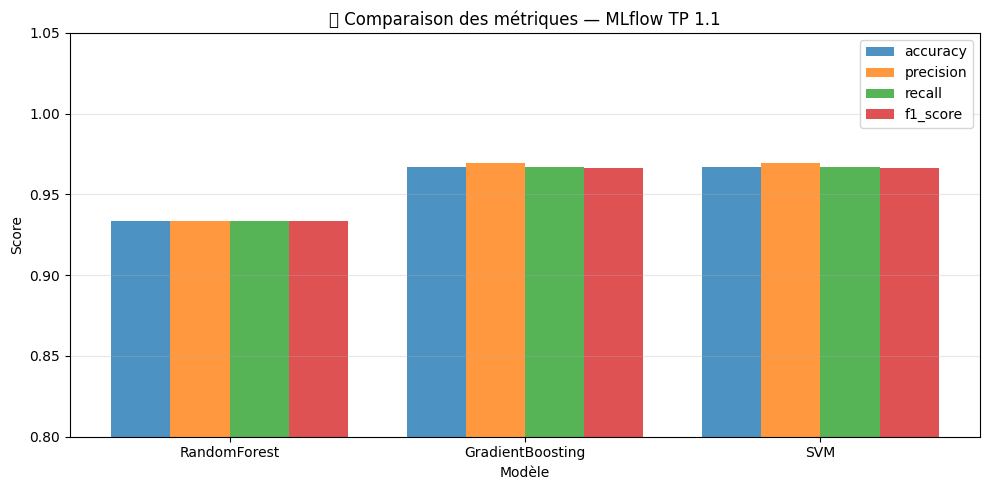

📸 Graphique sauvegardé : model_comparison.png


In [9]:
# ============================================================
# COMPARAISON DES RÉSULTATS
# ============================================================

results_df = pd.DataFrame(results).set_index('run_name')

print("📊 Tableau comparatif des 3 runs :")
print("=" * 70)
print(results_df[['model_type', 'accuracy', 'precision', 'recall', 'f1_score']].to_string())
print("=" * 70)

# Trouver le meilleur modèle
best_run = results_df['f1_score'].idxmax()
best_f1  = results_df['f1_score'].max()
best_run_id = results_df.loc[best_run, 'run_id']

print(f"\n🏆 Meilleur modèle : {best_run}")
print(f"   F1-Score       : {best_f1:.4f}")
print(f"   Run ID         : {best_run_id}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, alpha=0.8)

ax.set_xlabel('Modèle')
ax.set_ylabel('Score')
ax.set_title('📊 Comparaison des métriques — MLflow TP 1.1')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([r.split('_')[0] for r in results_df.index], rotation=0)
ax.set_ylim(0.8, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("📸 Graphique sauvegardé : model_comparison.png")

In [12]:
# ============================================================
# 💡 COMMENT VISUALISER DANS L'UI MLFLOW
# ============================================================

print("="*60)
print("🖥️  Pour ouvrir l'interface MLflow :")
print("="*60)
print()
print("   Dans un TERMINAL, exécute :")
print()
print("   $ mlflow ui --backend-store-uri ./mlruns")
print()
print("   Puis ouvre dans ton navigateur :")
print("   → http://localhost:5000")
print()
print("   Tu verras :")
print("   ✅ L'expérience 'iris_classification_tp1'")
print("   ✅ Les 3 runs avec leurs métriques")
print("   ✅ Les graphiques en artefacts")
print("   ✅ La comparaison visuelle des runs")
print("="*60)

# Récupérer les runs via l'API Python
client = MlflowClient()
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = client.search_runs(experiment.experiment_id)

print(f"\n📋 {len(runs)} runs trouvés dans MLflow via API Python")
for r in runs:
    print(f"   - {r.info.run_name:30s} | status: {r.info.status}")

🖥️  Pour ouvrir l'interface MLflow :

   Dans un TERMINAL, exécute :

   $ mlflow ui --backend-store-uri ./mlruns

   Puis ouvre dans ton navigateur :
   → http://localhost:5000

   Tu verras :
   ✅ L'expérience 'iris_classification_tp1'
   ✅ Les 3 runs avec leurs métriques
   ✅ Les graphiques en artefacts
   ✅ La comparaison visuelle des runs

📋 3 runs trouvés dans MLflow via API Python
   - SVM_v1                         | status: FINISHED
   - GradientBoosting_v1            | status: FINISHED
   - RandomForest_v1                | status: FINISHED


<a id='7'></a>
## 8. 🧪 TP 1.2 — MLflow Registry

### Objectif
Enregistrer le **meilleur modèle** dans le **MLflow Model Registry** avec gestion des stages.

### Cycle de vie d'un modèle dans le Registry

```
None → Staging → Production → Archived
  ↑         ↑          ↑           ↑
Nouveau   Tests OK   Déployé   Remplacé
```

| Stage | Signification |
|---|---|
| **None** | Modèle enregistré, en attente de validation |
| **Staging** | En cours de test, environnement de staging |
| **Production** | Déployé en production, utilisé par les clients |
| **Archived** | Remplacé par une version plus récente |

> 💰 **Fintech (Stripe, Square)** : Les systèmes de détection de fraude doivent être déployés instantanément. MLflow Registry permet des rollbacks automatiques en quelques secondes si un modèle cause trop de faux positifs.

In [13]:
# ============================================================
# TP 1.2 — ENREGISTRER LE MEILLEUR MODÈLE DANS LE REGISTRY
# ============================================================

MODEL_REGISTRY_NAME = "iris-classifier-production"

print(f"🏆 Enregistrement du meilleur modèle : {best_run}")
print(f"   Run ID : {best_run_id}")
print(f"   Nom dans le Registry : {MODEL_REGISTRY_NAME}")
print()

# Construire l'URI du modèle depuis le run
model_uri = f"runs:/{best_run_id}/model"

# Enregistrer dans le Registry
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=MODEL_REGISTRY_NAME
)

print(f"✅ Modèle enregistré !")
print(f"   Nom    : {registered_model.name}")
print(f"   Version: {registered_model.version}")
print(f"   Status : {registered_model.status}")

Successfully registered model 'iris-classifier-production'.
2026/03/16 09:41:30 WARNING mlflow.tracking._model_registry.fluent: Run with id 8cb3a162d594424ab43b1d35a61c8f9c has no artifacts at artifact path 'model', registering model based on models:/m-6b820f1a3b25466782ecfa6f608c1304 instead


🏆 Enregistrement du meilleur modèle : GradientBoosting_v1
   Run ID : 8cb3a162d594424ab43b1d35a61c8f9c
   Nom dans le Registry : iris-classifier-production

✅ Modèle enregistré !
   Nom    : iris-classifier-production
   Version: 1
   Status : READY


Created version '1' of model 'iris-classifier-production'.


In [14]:
# ============================================================
# GÉRER LES STAGES DU MODÈLE
# ============================================================
import time

client = MlflowClient()

# Attendre que le modèle soit prêt
time.sleep(2)

model_version = registered_model.version

# ---- 1. Passer en Staging ----
client.transition_model_version_stage(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    stage="Staging"
)
print(f"✅ Modèle v{model_version} → STAGING")

# Ajouter une description (bonne pratique)
client.update_model_version(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    description=f"Meilleur modèle du TP 1.1 - F1: {best_f1:.4f} - Run: {best_run}"
)

# ---- 2. Passer en Production ----
# En conditions réelles, on ferait des tests de staging d'abord
time.sleep(1)
client.transition_model_version_stage(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    stage="Production"
)
print(f"✅ Modèle v{model_version} → PRODUCTION 🚀")

# ---- 3. Ajouter des tags de gouvernance ----
client.set_model_version_tag(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    key="validated_by",
    value="MLOps_team"
)
client.set_model_version_tag(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    key="dataset",
    value="iris_v1"
)

print(f"\n📋 Tags de gouvernance ajoutés")
print(f"   - validated_by: MLOps_team")
print(f"   - dataset: iris_v1")

✅ Modèle v1 → STAGING
✅ Modèle v1 → PRODUCTION 🚀

📋 Tags de gouvernance ajoutés
   - validated_by: MLOps_team
   - dataset: iris_v1


In [15]:
# ============================================================
# CHARGER ET UTILISER LE MODÈLE DEPUIS LE REGISTRY
# ============================================================

print("🔄 Chargement du modèle depuis le Registry...")
print(f"   URI : models:/{MODEL_REGISTRY_NAME}/Production")
print()

# Charger le modèle en production
production_model = mlflow.sklearn.load_model(
    model_uri=f"models:/{MODEL_REGISTRY_NAME}/Production"
)

print("✅ Modèle chargé depuis le Registry !")
print(f"   Type : {type(production_model).__name__}")

# Faire des prédictions avec le modèle chargé
sample_data = X_test[:5]
predictions = production_model.predict(sample_data)
probabilities = production_model.predict_proba(sample_data)

print(f"\n🔮 Prédictions sur 5 nouveaux échantillons :")
print("-" * 50)
for i, (pred, probs) in enumerate(zip(predictions, probabilities)):
    species = iris.target_names[pred]
    confidence = probs[pred] * 100
    true_label = iris.target_names[y_test[i]]
    status = "✅" if pred == y_test[i] else "❌"
    print(f"  Sample {i+1}: Prédit={species:12s} | Confiance={confidence:.1f}% | Réel={true_label} {status}")

🔄 Chargement du modèle depuis le Registry...
   URI : models:/iris-classifier-production/Production

✅ Modèle chargé depuis le Registry !
   Type : GradientBoostingClassifier

🔮 Prédictions sur 5 nouveaux échantillons :
--------------------------------------------------
  Sample 1: Prédit=setosa       | Confiance=100.0% | Réel=setosa ✅
  Sample 2: Prédit=virginica    | Confiance=99.7% | Réel=virginica ✅
  Sample 3: Prédit=versicolor   | Confiance=100.0% | Réel=versicolor ✅
  Sample 4: Prédit=versicolor   | Confiance=100.0% | Réel=versicolor ✅
  Sample 5: Prédit=setosa       | Confiance=100.0% | Réel=setosa ✅


In [16]:
# ============================================================
# INSPECTER LE REGISTRY — Vue d'ensemble
# ============================================================

print("="*60)
print("📦 ÉTAT DU MLFLOW MODEL REGISTRY")
print("="*60)

# Lister tous les modèles enregistrés
for rm in client.search_registered_models():
    print(f"\n🏷️  Modèle : {rm.name}")
    print(f"   Description : {rm.description or 'N/A'}")
    
    for version in client.search_model_versions(f"name='{rm.name}'"):
        print(f"\n   📌 Version {version.version}:")
        print(f"      Stage       : {version.current_stage}")
        print(f"      Run ID      : {version.run_id[:8]}...")
        print(f"      Description : {version.description or 'N/A'}")
        print(f"      Tags        : {dict(version.tags)}")

print("\n" + "="*60)
print("💡 Dans l'UI MLflow → onglet 'Models' pour voir tout ça !")
print("="*60)

📦 ÉTAT DU MLFLOW MODEL REGISTRY

🏷️  Modèle : iris-classifier-production
   Description : N/A

   📌 Version 1:
      Stage       : Production
      Run ID      : 8cb3a162...
      Description : Meilleur modèle du TP 1.1 - F1: 0.9666 - Run: GradientBoosting_v1
      Tags        : {'dataset': 'iris_v1', 'validated_by': 'MLOps_team'}

💡 Dans l'UI MLflow → onglet 'Models' pour voir tout ça !


In [17]:
# ============================================================
# BONUS : DÉMONSTRATION D'UN ROLLBACK
# ============================================================
# Scénario : le modèle v1 en production pose un problème.
# On l'archive et on revient... à rien dans ce cas (pas de v2)
# mais en conditions réelles, on ferait :
#   1. Archiver v2 (nouvelle version défaillante)
#   2. Remettre v1 en Production

print("🔄 Simulation d'un Rollback :")
print()
print("Scénario : Le modèle v1 en prod commence à dégrader...")
print()

# Archiver le modèle actuel
client.transition_model_version_stage(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    stage="Archived"
)
print(f"   ⚠️  Modèle v{model_version} archivé (rollback déclenché)")

# En prod, on remettrait la version précédente en Production
# Ici on replace en Production pour le TP
client.transition_model_version_stage(
    name=MODEL_REGISTRY_NAME,
    version=model_version,
    stage="Production"
)
print(f"   ✅ Modèle v{model_version} remis en Production (rollback terminé)")
print()
print("💡 Avec MLOps : rollback en quelques secondes vs. plusieurs heures manuellement")

🔄 Simulation d'un Rollback :

Scénario : Le modèle v1 en prod commence à dégrader...

   ⚠️  Modèle v1 archivé (rollback déclenché)
   ✅ Modèle v1 remis en Production (rollback terminé)

💡 Avec MLOps : rollback en quelques secondes vs. plusieurs heures manuellement


## 9. 📊 Analyse Détaillée du Meilleur Modèle

📋 Classification Report — Meilleur modèle :
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



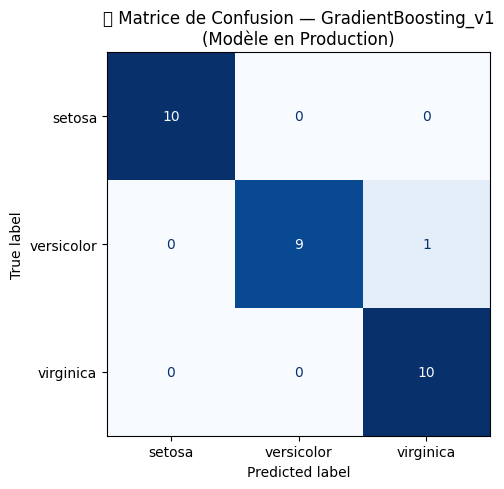

📸 Matrice sauvegardée : confusion_matrix.png


In [18]:
# ============================================================
# ANALYSE COMPLÈTE DU MEILLEUR MODÈLE
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Prédictions sur tout le test set
y_pred_final = production_model.predict(X_test)

# Classification report complet
print("📋 Classification Report — Meilleur modèle :")
print("=" * 55)
print(classification_report(y_test, y_pred_final, target_names=iris.target_names))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'🔷 Matrice de Confusion — {best_run}\n(Modèle en Production)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("📸 Matrice sauvegardée : confusion_matrix.png")

<a id='9'></a>
## 10. 📝 Résumé et Bilan du Jour 1

### ✅ Ce que tu as appris aujourd'hui

| Concept | Ce que tu as fait |
|---|---|
| **Problèmes MLOps** | Compris le fossé dev ↔ prod, data drift, reproductibilité |
| **5 Piliers MLOps** | Reproductibilité, Automation, Monitoring, Versioning, Collaboration |
| **Seeds** | Fixé les seeds pour garantir la reproductibilité |
| **MLflow Tracking** | Loggé 3 runs avec params + métriques + modèles + artefacts |
| **MLflow Registry** | Enregistré le meilleur modèle, géré les stages (Staging → Production) |
| **Rollback** | Simulé un rollback de modèle en quelques secondes |

### 🎯 Points clés à retenir

1. **MLOps résout le problème** : *"mon modèle marche en dev mais pas en prod"*
2. **Les 5 piliers** : reproductibilité, automation, monitoring, versioning, collaboration
3. **MLflow** est le standard pour tracking et registry
4. **Seeds fixes + MLflow tracking** = reproductibilité garantie
5. **Le cycle ML a 3 boucles** : expérimentation, production, retraining

### 🚀 Demain — Jour 2
Tu iras plus loin avec les **pipelines automatisés** :
- Aujourd'hui, tu as tracké **manuellement**
- Demain, tu automatiseras le training et le déploiement avec **Apache Airflow** et **CI/CD**

---

### 📁 Fichiers générés
```
jour1/
├── jour1_mlops_fondements.ipynb   ← ce notebook
├── mlruns/                         ← données MLflow (auto-généré)
├── iris_exploration.png
├── model_comparison.png
└── confusion_matrix.png
```

In [19]:
# ============================================================
# ✅ VÉRIFICATION FINALE — Bilan du Jour 1
# ============================================================

print("=" * 65)
print("         🎉 BILAN JOUR 1 — MLOPS FONDEMENTS")
print("=" * 65)
print()

# Récapitulatif MLflow
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
runs = client.search_runs(experiment.experiment_id)
print(f"📊 MLflow Tracking :")
print(f"   Expérience   : {EXPERIMENT_NAME}")
print(f"   Runs créés   : {len(runs)}")
print()

# Récapitulatif Registry
versions = client.search_model_versions(f"name='{MODEL_REGISTRY_NAME}'")
print(f"📦 MLflow Registry :")
print(f"   Modèle enregistré : {MODEL_REGISTRY_NAME}")
print(f"   Versions          : {len(versions)}")
prod_versions = [v for v in versions if v.current_stage == 'Production']
print(f"   En Production     : {len(prod_versions)}")
print()

# Meilleur modèle
print(f"🏆 Meilleur modèle :")
print(f"   Nom       : {best_run}")
print(f"   F1-Score  : {best_f1:.4f}")
print(f"   Accuracy  : {results_df.loc[best_run, 'accuracy']:.4f}")
print()

print("=" * 65)
print("  ✅ TP 1.1 — MLflow Tracking     : TERMINÉ")
print("  ✅ TP 1.2 — MLflow Registry     : TERMINÉ")
print("  ✅ Reproductibilité (seeds)     : IMPLÉMENTÉE")
print("  ✅ Rollback simulation          : DÉMONTRÉE")
print("=" * 65)
print()
print("  🖥️  Lance 'mlflow ui' dans ton terminal pour explorer !")
print("=" * 65)

         🎉 BILAN JOUR 1 — MLOPS FONDEMENTS

📊 MLflow Tracking :
   Expérience   : iris_classification_tp1
   Runs créés   : 3

📦 MLflow Registry :
   Modèle enregistré : iris-classifier-production
   Versions          : 1
   En Production     : 1

🏆 Meilleur modèle :
   Nom       : GradientBoosting_v1
   F1-Score  : 0.9666
   Accuracy  : 0.9667

  ✅ TP 1.1 — MLflow Tracking     : TERMINÉ
  ✅ TP 1.2 — MLflow Registry     : TERMINÉ
  ✅ Reproductibilité (seeds)     : IMPLÉMENTÉE
  ✅ Rollback simulation          : DÉMONTRÉE

  🖥️  Lance 'mlflow ui' dans ton terminal pour explorer !
